#Importing libaries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("cleaned_data.csv", encoding="utf-8")

Saving cleaned_data.csv to cleaned_data (4).csv


#Overview of data

In [ ]:
df.shape

(19853, 12)

In [ ]:
df.head(100)

,id,Brand,Model,Year,Category,Engine Size (cc),Power (hp),Engine Cylinder,Fuel Capacity (Lts),Weight (kg),Seat Height (mm),Power-to-Weight (hp/kg)
31,41,Adiva,ad tre,2014,Scooter,205,20.6,Single cylinder,13.0,118.0,740.0,0.17
32,42,Adiva,ad tre 55,2014,Scooter,205,20.6,Single cylinder,13.0,215.0,740.0,0.10
34,46,Adiva,ad3 300,2019,Scooter,299,29.4,Single cylinder,11.0,202.0,700.0,0.15
35,47,Adiva,ad3 300lt,2020,Scooter,299,29.4,Single cylinder,12.2,202.0,700.0,0.15
36,48,Adiva,ad3 400,2018,Scooter,399,36.7,Single cylinder,11.0,257.0,770.0,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...
212,448,Ajs,eos 125 mk2,2011,Custom / Cruiser,125,11.0,Twin,14.0,180.0,640.0,0.06
213,449,Ajs,eos 125 mk2,2015,Custom / Cruiser,125,11.0,Twin,14.0,180.0,640.0,0.06
214,450,Ajs,eos 350,2015,Custom / Cruiser,320,23.0,Twin,14.0,191.0,640.0,0.12
215,451,Ajs,exactly 125,2010,Scooter,124,6.2,Single cylinder,4.7,89.0,775.0,0.07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19853 entries, 0 to 19852
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 19853 non-null  int64 
 1   brand              19853 non-null  object
 2   model              19853 non-null  object
 3   year               19853 non-null  int64 
 4   category           19853 non-null  object
 5   rating             19853 non-null  object
 6   displacement_ccm   19853 non-null  object
 7   power_hp           19853 non-null  object
 8   engine_cylinder    19853 non-null  object
 9   fuel_capacity_lts  19853 non-null  object
 10  dry_weight_kg      19853 non-null  object
 11  seat_height_mm     19853 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


In [ ]:
df.describe()

,id,year
count,19853.000000,19853.000000
mean,19726.501637,2015.723165
std,11188.465421,3.857230
min,1.000000,2010.000000
25%,9730.000000,2012.000000
50%,19929.000000,2016.000000
75%,29735.000000,2019.000000
max,38299.000000,2022.000000


In [ ]:
numeric_columns = [
    "displacement_ccm",
    "power_hp",
    "fuel_capacity_lts",
    "dry_weight_kg",
    "seat_height_mm"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .str.extract(r'(\d+\.?\d*)')[0]
        .astype(float)
    )

In [ ]:
#checking number of null values
df.isnull().sum()

,0
id,0
brand,0
model,0
year,0
category,0
rating,0
displacement_ccm,963
power_hp,7054
engine_cylinder,0
fuel_capacity_lts,2261


In [ ]:
# removing rating attribute, too many missing values and not relevant
df.drop(columns=["rating"], inplace=True)

In [ ]:
df = df.dropna(
    subset=[
        "power_hp",
        "dry_weight_kg",
        "displacement_ccm",
        "seat_height_mm",
        "fuel_capacity_lts"
    ]
)

In [ ]:
# Clean numeric formatting
df["power_hp"] = df["power_hp"].round(1)
df["dry_weight_kg"] = df["dry_weight_kg"].round(1)
df["displacement_ccm"] = df["displacement_ccm"].round(0).astype(int)

In [ ]:
df["Power-to-Weight (hp/kg)"] = (
    df["power_hp"] / df["dry_weight_kg"]
)

df["Power-to-Weight (hp/kg)"] = df["Power-to-Weight (hp/kg)"].round(2)

In [ ]:
df = df.rename(columns={
    "displacement_ccm": "Engine Size (cc)",
    "power_hp": "Power (hp)",
    "dry_weight_kg": "Weight (kg)",
    "brand": "Brand",
    "model": "Model",
    "year": "Year",
    "category": "Category",
    "engine_cylinder": "Engine Cylinder",
    "seat_height_mm": "Seat Height (mm)",
    "fuel_capacity_lts": "Fuel Capacity (Lts)",
    "power_to_weight": "Power-to-Weight (hp/kg)"
})

In [ ]:
df["Brand"] = df["Brand"].str.title()
df["Category"] = df["Category"].str.title()

In [ ]:
# Export
df.to_csv("motorcycles_clean.csv", index=False)

In [ ]:
files.download("motorcycles_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#EDA

##Motorcycle market analysis

###How many motorcycles belong to each brand?

In [ ]:
unique_brands = df['brand'].unique()

print(unique_brands)

['acabion' 'access' 'adiva' 'adly' 'aeon' 'ajp' 'ajs' 'alfer' 'alligator'
 'alta' 'american ironhorse' 'aprilia' 'ariel' 'apsonic' 'arch'
 'arctic cat' 'arlen ness' 'arqin' 'askoll' 'aspes' 'ather' 'atk' 'bmw'
 'atlas honda' 'aurora' 'avanturaa choppers' 'avinton' 'avon' 'azel'
 'bajaj' 'baltmotors' 'bamx' 'brixton' 'baotian' 'beeline' 'benelli'
 'bennche' 'beta' 'big bear choppers' 'big dog' 'bimota' 'bintelli'
 'black douglas' 'blata' 'bluroc' 'bmc choppers' 'brough superior' 'derbi'
 'boom trikes' 'borile' 'boss hoss' 'bourget' 'bpg' 'brammo' 'brudeli'
 'bsa' 'buccimoto' 'buell' 'bullit' 'bultaco' 'cagiva'
 'california scooter' 'can-am' 'capirelli' 'cargobike' 'caterham' 'ccm'
 'cectek' 'cf moto' 'ch racing' 'chang-jiang' 'cheetah' 'christini'
 'cleveland' 'clipic' 'cmc' 'cobra' 'combat motors' 'confederate'
 'cosmos muscle bikes' 'covingtons' 'cpi' 'cr&s' 'csc motorcycles' 'csr'
 'current motor' 'curtiss' 'daelim' 'dafier' 'dafra' 'dam' 'damon'
 'db motors' 'delfast' 'demak' 'derri

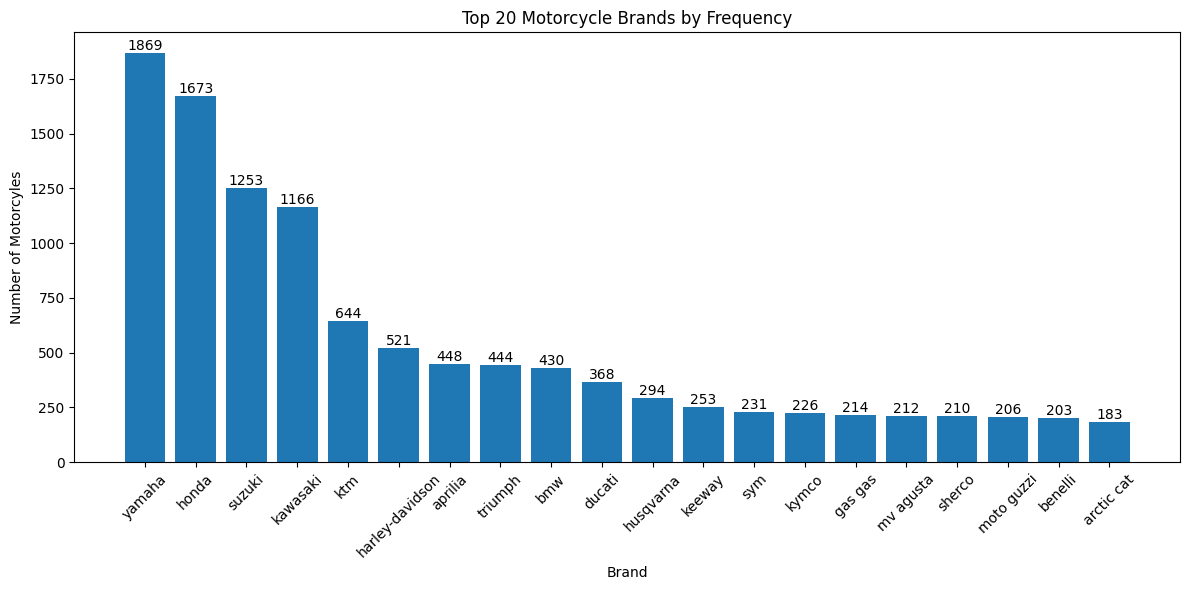

In [ ]:
top_brands = df['brand'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_brands.index, top_brands.values)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

ax.set_title("Top 20 Motorcycle Brands by Frequency")
ax.set_xlabel("Brand")
ax.set_ylabel("Number of Motorcyles")


ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

###How many motorcycles belong to each category?

In [ ]:
unique_category = df['category'].unique()

print(unique_category)

['Prototype / concept model' 'Scooter' 'ATV' 'Minibike, sport' 'Allround'
 'Minibike, cross' 'Enduro / offroad' 'Super motard' 'Cross / motocross'
 'Sport' 'Custom / cruiser' 'Classic' 'Trial' 'Naked bike' 'Sport touring'
 'Touring']


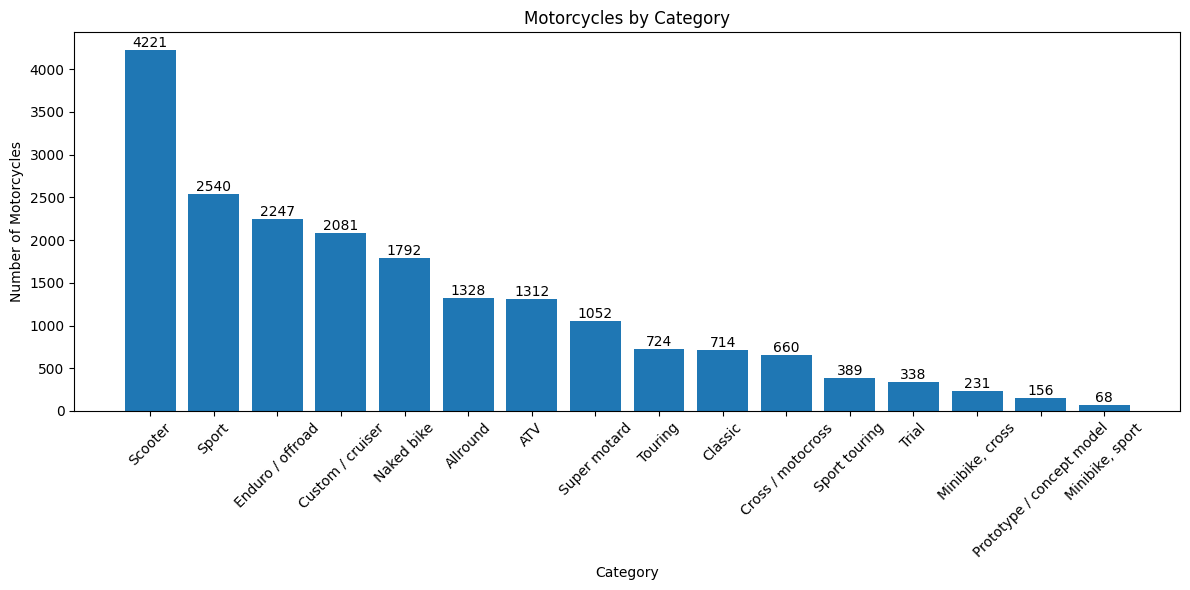

In [ ]:
category_bikes = df['category'].dropna().value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(category_bikes.index, category_bikes.values)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

ax.set_title("Motorcycles by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Motorcycles")

ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Distribution of motorcycles across years?

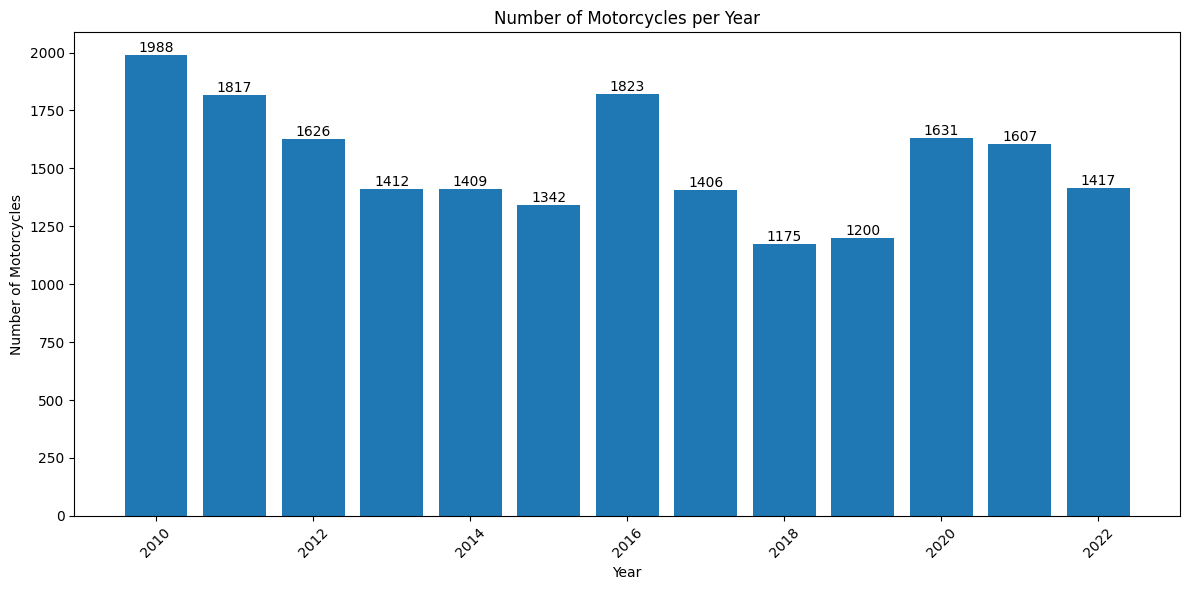

In [ ]:
year_counts = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(year_counts.index, year_counts.values)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

ax.set_title("Number of Motorcycles per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Motorcycles")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Displacement vs Power

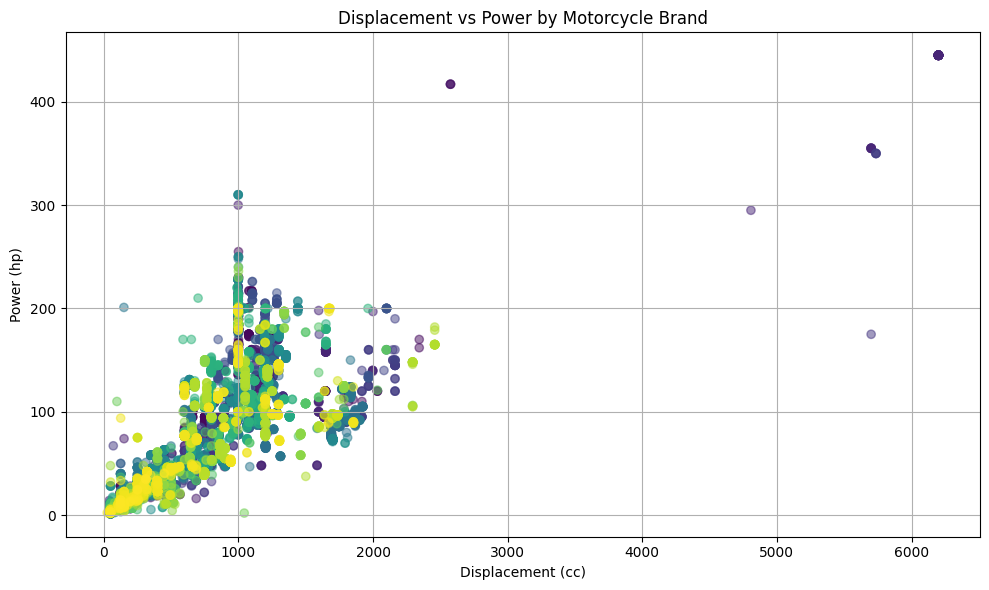

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

brands = df["brand"].astype("category").cat.codes

x = df["Engine Size (cc)"]
y = df["Power (hp)"]
scatter = ax.scatter(
    x,
    y,
    c=brands,
    alpha=0.5
)

ax.set_title("Displacement vs Power by Motorcycle Brand")
ax.set_xlabel("Displacement (cc)")
ax.set_ylabel("Power (hp)")

ax.grid(True)
plt.tight_layout()
plt.show()

### Weight vs Power-to-Weight Ratio

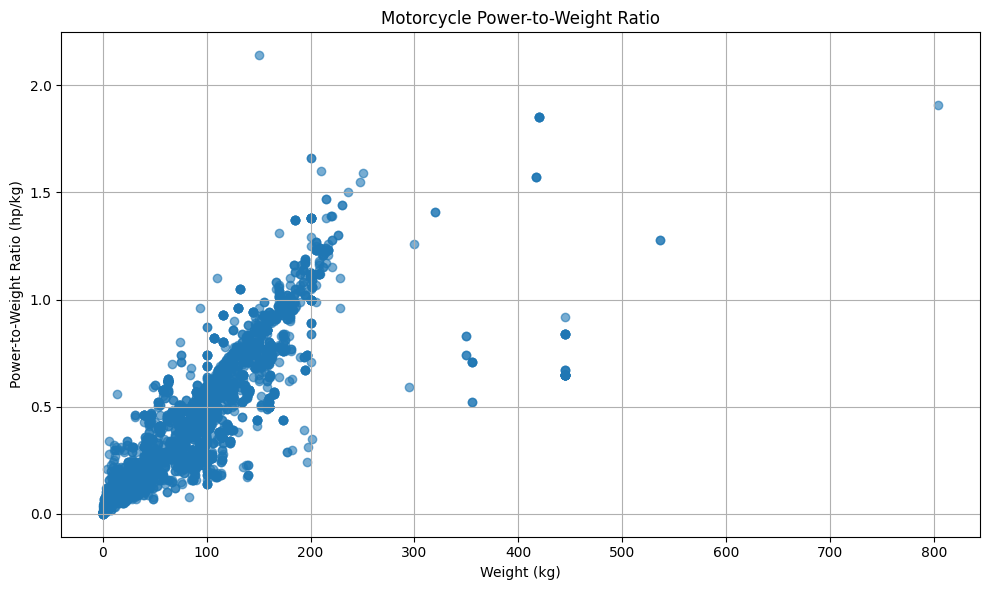

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["Power (hp)"],
    df["Power-to-Weight (hp/kg)"],
    alpha=0.6
)

ax.set_title("Motorcycle Power-to-Weight Ratio")
ax.set_xlabel("Weight (kg)")
ax.set_ylabel("Power-to-Weight Ratio (hp/kg)")

ax.grid(True)

plt.tight_layout()
plt.show()